# Congestion & Constraint Management at the Seam 

> **Work in progress** — an illustrative teaching notebook under active development, not an authoritative reference.

Two market engines share one grid and each dispatches
its own resources, serves its own loads, and enforces limits only on its own
activated constraint set. Network elements are jointly impacted by both dispatches as a result of the superposition of flows. This notebook considers management of shared loading.

The seams issue associated with congestion management can be categorized by the direction and timing of the risk. On **direction** of the miss, the neighbor's flow can be under- or
over-accommodated. On **timing** of the response, it can be addressed
ex ante (before the market runs) or ex post (after the market runs).

| | **ex ante** — before the market run | **ex post** — after the market run |
|---|---|---|
| **Under-accommodation** | Ignore or under-estimate the neighbour's flow and the line can overload while both dispatches are independently feasible. | Not applicable. |
| **Over-accommodation** | Reserve headroom or over-estimate the neighbour's flow and phantom congestion or unused transmission results. | Blunt curtailments or schedule cuts applied until the line falls within its operating limit with a tendency to overshoot the exact need. |

Ex ante the headroom is set before the market runs, and it can be
set too small or too large. A dial is used in this notebook to explore the impact. 
Ex post does not allow under-relief, so after-the-fact correction generally
ends as over-accommodation. The sections here price real-time relief as if it
clears the exceedance exactly — redispatch in the engine is continuous — at a
premium the host pays for the whole exceedance even though it caused only part
of the loading. Lumpy relief and shared relief is addressed only
narratively here and left for subsequent notebooks.

The sections build both failure modes on the WSCC 9-bus network, and price
each one deterministically.

The formulation is built on the 202 Market Seam notebook. Everything runs on the shared libraries — `wscc9_model`, `footprints`,
`seams_engine`, `wscc9_figures`, `risk`.


## 0. Setup


In [1]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py",
               "wscc9_model.py", "footprints.py", "revenue_allocation.py",
               "wscc9_figures.py", "atc.py", "bilateral.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

# Teaching libraries for the WSCC 9-bus illustrative repository.
import seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures
for _m in (seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures):
    importlib.reload(_m)
import wscc9_model as wm, footprints as fpmod, revenue_allocation as ra, wscc9_figures as figs
from wscc9_model import (
    build_network, make_engine, shift_factors, sf_table,
    BUS_COLORS, COORDS, RING_ORDER, ROTATION_DEG, CENTER_BUS,
)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
    shed_segments, served_by_bus, served_demand,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize, plot_combined_letter,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)

def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='', float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'

try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

print('ready')

ready


In [3]:
# The teaching fleet and loads live in wscc9_model (edit there, or override the
# dicts here). Bus 3 is the cheapest unit ($20), bus 1 the most expensive ($50).
GEN_FLEET = dict(wm.DEFAULT_GEN_FLEET)   # {gen: {bus, cost $/MWh, p_nom MW}}
LOADS     = dict(wm.DEFAULT_LOADS)       # {bus: MW}
print('loads (MW):', LOADS)
pd.DataFrame(GEN_FLEET).T[['bus', 'cost', 'p_nom']]

loads (MW): {'5': 90.0, '7': 100.0, '9': 125.0}


,bus,cost,p_nom
gen_slack_0,1,50.0,250.0
gen_0,2,35.0,300.0
gen_1,3,20.0,170.0


## 1. The engine, its own flow, and the superposition

**Nomenclature.** Sets are script capitals; an element is the matching
lower-case letter (upper-case for markets). The `Code` column is where each
object lives in the shared libraries.

| Symbol | Code | Definition |
|---|---|---|
| $\mathcal N$, $\mathcal M$ | `pt.buses` / `pt.lines` | buses, and the **network line set** — every line in the shared network |
| $SF_{n,m}$, $\bar F_m$ | `shift_factors()` / `LINE_RATINGS` | shift factor of bus $n$ on line $m$; line $m$'s rating — shared physics, owned by no engine |
| $\mathcal E$, $M$ | `make_engine` | the set of market engines; $M\in\mathcal E=\{A,B\}$ |
| $\mathcal R^{M}$, $d^M_n$ | `eng.gens` / `eng.loads` | the resources market $M$ dispatches and the loads it serves |
| $\mathcal M^{M}_{\text{mon}}\subseteq\mathcal M$ | `MONITORED_LINES` | market $M$'s **monitored lines** — the subset of the network line set it models and watches |
| $\mathcal M^{M}_{\text{act}}\subseteq\mathcal M^{M}_{\text{mon}}$ | `ACTIVATED_LINES` (`eng.activated_lines`) | the **activated constraint set** — the monitored lines whose limits market $M$ enforces |
| $g^{M}_i$, $p^{\mathrm{inj},M}_n$ | `res.dispatch` / `res.injection` | dispatch, and market $M$'s net injection at bus $n$: own dispatch minus own load plus the exogenous schedules, $g^{M}_{(n)}-d^{M}_n+\mathrm{exo}^{M}_n$ |
| $\mathrm{exo}^{M}_n$ | `exo=` | the **exogenous injections and withdrawals** market $M$ carries in its model — forecast schedules from elsewhere on the network, fixed before the clear |
| $F^{M}_m$ | `res.flow_own` | market $M$'s **own** flow on line $m$ — computed for every line, priced only on $\mathcal M^{M}_{\text{act}}$ |
| $F^{s}_m$ | `physical_flows` (`F^s` at display) | the **superposed flow** $\sum_M F^{M}_m$ — what the transmission element actually carries |
| $\lambda^{M}$, $\lambda^{M}_n$, $\mu^{M}_m$ | `res.energy_price` / `res.lmp` / `res.line_dual` | market $M$'s energy price, nodal LMP, and signed line dual |
| $\hat g_i$, $g^{\downarrow}_i$, $g^{\uparrow}_i$, $\pi$ | Section 4 | the day-ahead schedule, its re-offer, the increment above it, and the real-time premium |
| $\Delta C^{\mathrm{RT}}$ | Section 4 | the real-time bill — real-time cost over day-ahead |
| $\lambda^{\mathrm{DA}}_n$, $\lambda^{\mathrm{RT}}_n$ | `res.lmp` at each clearing | the day-ahead and real-time nodal prices at bus $n$ |
| $\Pi_i$ | Section 4 | resource $i$'s **two-settlement payment** — its schedule at day-ahead prices plus its deviation at real-time prices |
| $R^{\mathrm{DA}}$, $R^{\mathrm{RT}}$ | Section 4 | the operator's **net position** in each settlement: what load pays less what generation is paid, at that settlement's prices and over that settlement's quantities |
| $\widehat F^{M'}_m$, $\beta$, $F^{M',\mathrm{ref}}_m$ | `flow_offsets`, `ATC_MARGIN` | the reservation for the other market's flow; the conservatism margin; the reference flow it scales |


Each market $M \in \mathcal E = \{A, B\}$ is a clearing engine with a resource stack $\mathcal R^M$, a load set, and an activated constraint
set $\mathcal M^M_{\mathrm{act}}$ that is a subset of the lines it monitors,
$\mathcal M^M_{\mathrm{mon}}$, on the shared network. It clears the
dispatch over its **own** sets:

$$\min_{g}\ \sum_{i\in\mathcal R^{M}} c_i\,g^{M}_i \quad\text{s.t.}\quad \sum_{i} g^{M}_i = \sum_{n} d^{M}_n\ \ [\lambda^{M}],\qquad -\bar F_m \le F^{M}_m \le \bar F_m\ \ [\mu^{M}_m],\ m\in\mathcal M^{M}_{\text{act}}. \tag{1}$$

*In words.* Market $M$ minimizes the offer cost of its own dispatch,
$\sum c_i\,g^{M}_i$ over its resource set $\mathcal R^{M}$, subject to its
generation equalling its served load (dual $\lambda^{M}$, its energy price)
and its own flow $F^{M}_m$ staying within the rating $\bar F_m$ on each
activated line $m\in\mathcal M^{M}_{\text{act}}$ (dual $\mu^{M}_m$).

**Each market's own flow.** The injections a market
computes flows from are its own dispatch and load, plus
the exogenous injections and withdrawals from elsewhere on the network. The exogenous injections and withdrawals are based on fixed forecasts,
$p^{\mathrm{inj},M}_n = g^{M}_{(n)} - d^{M}_n + \mathrm{exo}^{M}_n$.

$$F^M_m=\sum_{n\in\mathcal N} SF_{n,m}\,p^{\mathrm{inj},M}_n\qquad (m\in\mathcal M). \tag{2}$$

*In words.* Market $M$'s computed flow $F^M_m$ on line $m$ sums the shift
factor $SF_{n,m}$ against its net injection $p^{\mathrm{inj},M}_n$ at every
bus, $m\in\mathcal M$.

**Ignoring the neighbor.** The worked examples in this
notebook are deliberately blind: the forecast injections and withdrawals from
outside the market footprint are ignored, $\mathrm{exo}^{M}_n = 0$ at every
bus, so the injection reduces to $p^{\mathrm{inj},M}_n = g^{M}_{(n)} - d^{M}_n$
and (2) is computed as

$$F^M_m=\sum_{n\in\mathcal N} SF_{n,m}\,\big(g^{M}_{(n)} - d^{M}_n\big)\qquad (m\in\mathcal M),$$

with the other market's injections contributing **zero** to $F^M_m$ even
though their shift factors are non-zero. The examples are used here for teaching purposes. Section 5 incorporates an exogenous flow forecast on the activated-line $\widehat F^{M'}_m$
(`flow_offsets`).

**The superposed flow is the sum of both.** Under the DC approximation flows
are linear in injections, so the components superpose to $F^{s}_m$.

$$F^{s}_m=\sum_{n\in\mathcal N} SF_{n,m}\Big(\sum_{M\in\mathcal E}p^{\mathrm{inj},M}_n\Big)=\sum_{M\in\mathcal E}F^M_m\qquad (m\in\mathcal M). \tag{3}$$

*In words.* The superposed flow $F^{s}_m$ on line $m$ sums the shift factor
$SF_{n,m}$ against the net injections of every market together, and that
equals the sum of each market's own flow $F^{M}_m$ over the engine set
$\mathcal E$.

**What each market enforces vs. the flows.**

$$\underbrace{\;|F^M_m|\le \bar F_m\ \ \forall M\in\mathcal E\;}_{\text{each market — its own component}}
  \qquad\Longrightarrow\!\!\!\!\!\diagup\qquad
  \underbrace{\;\Big|\textstyle\sum_{M\in\mathcal E} F^M_m\Big|\le \bar F_m\;}_{\text{transmission element — the total}} \tag{4}$$

*In words.* On the left, each market $M$ keeps the absolute value of its own
component $|F^{M}_m|$ within the rating $\bar F_m$; on the right, the transmission element
needs the absolute value of the **sum** $|\sum_M F^{M}_m|$ within the same
rating; the struck arrow says the left does not imply the right.

When the two components share a sign, the physical flow can exceed the limit
while every market reports a feasible, within-limits dispatch.


## 2. Two market footprints on the shared network

The same 9-bus nodal network, now partitioned into **two market footprints**
that clear independently. Each market:

- optimises only its own generators against its own load (plus any scheduled interchange),
- enforces line limits only on its **own** computed flow component $F^M_m$,
  and only on the lines it activates ($\mathcal M^M_{\mathrm{act}}$, a subset of
  the lines it monitors),
- treats the other market's dispatch as exogenous.

The footprints:

- **Market A** = buses {2, 8, 7, 6, 3}, fleet (gen_1 \$20 @ bus 3,
  gen_0 \$35 @ bus 2), and the load at bus 7.
- **Market B** = buses {1, 9, 4, 5}, fleet (gen_slack_0 \$50 @ bus 1),
  and loads at buses 5 and 9.

The partition leaves exactly two **intertie lines** between the markets: `line_2`
(5-6) and `line_7` (8-9). Every other line is internal to one market. Formally the two markets are the
members of the engine set $\mathcal E=\{\mathrm{A},\mathrm{B}\}$ of Section 1; each $M\in\mathcal E$ clears (1) over its own
$\mathcal R^M$, its own loads, and its own activated set
$\mathcal M^M_{\mathrm{act}}$.

The partition assigns every **bus** to exactly one market. It does not assign
the **lines**. Which elements a market monitors — and which of those it
activates — is a separate design choice: a market can monitor a tie, or a path
inside its neighbour's footprint, and two markets can monitor the same
element. The config cell below makes both choices explicit: `MONITORED_LINES`
lists each market's $\mathcal M^M_{\mathrm{mon}}$ and `ACTIVATED_LINES` its
$\mathcal M^M_{\mathrm{act}}$, **line by line**, so every assignment is
visible and editable. The natural default gives each market the lines with
both ends inside its footprint, activates everything monitored, and places the
two intertie lines explicitly — `line_2` with **Market A** and `line_7` with
**Market B**. Edit the lists to move, share, or drop elements; a line in no
market's set is watched by neither.

*Reading the figures below.* Lines are coloured by the market that monitors them
(Market A purple, Market B blue); a line stays grey when it sits in no market's
monitored set — or in both — and any line that turns bright red is overloaded,
which overrides its market colour.

In [4]:
## -- EDIT -- the two market footprints (buses) and each market's monitored lines.
MKT_DEFS = {
    'Market A': ['2', '8', '7', '6', '3'],   # cheap fleet (bus 3 $20, bus 2 $35); load at 7 -> exporter
    'Market B': ['1', '9', '4', '5'],         # only the expensive bus-1 unit ($50); loads 5, 9 -> importer
}
MARKET_COLORS = {'Market A': '#993AFF', 'Market B': '#2471A3'}
# Each market's monitored set M^M_act. Every line listed explicitly; move a line,
# share it (list under both), or drop it (a line in no set draws grey).
MONITORED_LINES = {   # M^M_mon -- the lines each market models and watches
    'Market A': ['line_2', 'line_3', 'line_4', 'line_5', 'line_6'],   # line_2 = intertie 5-6
    'Market B': ['line_0', 'line_1', 'line_7', 'line_8'],             # line_7 = intertie 8-9
}
ACTIVATED_LINES = {   # M^M_act -- the monitored lines whose limits enter the clearing
    'Market A': ['line_2', 'line_3', 'line_4', 'line_5', 'line_6'],
    'Market B': ['line_0', 'line_1', 'line_7', 'line_8'],
}
# ---------------------------------------------------------------------------
pt = shift_factors()
fp = fpmod.make(pt, MKT_DEFS, MARKET_COLORS, monitored=MONITORED_LINES, tie_label='intertie')

# Notebook aliases so the cells below read naturally.
mkt_of = fp.fp_of
bus_to_mkt = fp.bus_to_fp
line_kind = lambda _pt, l: fp.line_kind(_pt, l)
seam_lines = fp.ties
monitored_by = lambda l: fp.monitored_by(l)
market_line_colors = lambda _pt: fp.line_colors(_pt)
MKT_GROUPS = fp.groups(pt)
internal = {m: [l for l in pt.lines if fp.line_kind(pt, l) == ('internal', m)] for m in MKT_DEFS}

for _m in MKT_DEFS:   # activation is a subset of monitoring -- clip and say so
    _extra = [l for l in ACTIVATED_LINES[_m] if l not in MONITORED_LINES[_m]]
    if _extra:
        print(f'[!] {_m}: {_extra} activated but not monitored -> dropped (M_act within M_mon)')
        ACTIVATED_LINES[_m] = [l for l in ACTIVATED_LINES[_m] if l in MONITORED_LINES[_m]]

A = make_engine('Market A', MKT_DEFS['Market A'], activated=ACTIVATED_LINES['Market A'])
B = make_engine('Market B', MKT_DEFS['Market B'], activated=ACTIVATED_LINES['Market B'])

def _status(l, m):
    if l in ACTIVATED_LINES[m]:  return 'enforces'
    if l in MONITORED_LINES[m]:  return 'monitors'
    return '--'
_rows = []
for l in pt.lines:
    b0, b1 = pt.line_buses[pt.line_idx[l]]
    loc = 'intertie' if l in seam_lines else f'internal {mkt_of(b0)}'
    _rows.append({'line': l, 'ends': f'{b0}-{b1}', 'location': loc,
                  **{m: _status(l, m) for m in MKT_DEFS}})
print('intertie lines (crossing the partition):', ', '.join(seam_lines),
      '-- monitoring and activation are configuration, not topology.')
display(pd.DataFrame(_rows).set_index('line'))

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


intertie lines (crossing the partition): line_2, line_7 -- monitoring and activation are configuration, not topology.


,ends,location,Market A,Market B
line,,,,
line_0,1-4,internal Market B,--,enforces
line_1,4-5,internal Market B,--,enforces
line_2,5-6,intertie,enforces,--
line_3,3-6,internal Market A,enforces,--
line_4,6-7,internal Market A,enforces,--
line_5,7-8,internal Market A,enforces,--
line_6,8-2,internal Market A,enforces,--
line_7,8-9,intertie,--,enforces
line_8,9-4,internal Market B,--,enforces


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


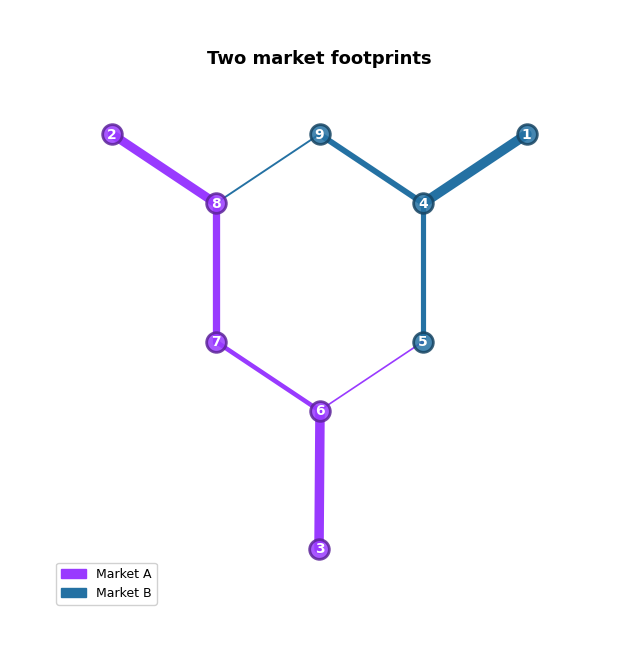

In [5]:
# Map of the two market footprints (buses and lines coloured by market; interties grey).
mkt_bus_colors = {b: MARKET_COLORS[mkt_of(b)] for b in pt.buses}
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=mkt_bus_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines}, line_widths=susceptance_widths(pt),
    line_colors=market_line_colors(pt),   # lines coloured by the monitoring market; unmonitored grey
    title='Two market footprints',
)
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=MARKET_COLORS[m], label=m) for m in MKT_DEFS],
          loc='lower left', fontsize=9, framealpha=0.9)
plt.show()

In [6]:
# One market's clearing as a combined set (network + nodal dispatch), the other
# footprint greyed. Implemented by wscc9_figures.footprint_figure; bound to fp.
# A self-schedule (exo_sched) draws grey at the LMP (price-taking, not optimised);
# pass sup_dem to take full control of the bars (e.g. a dedicated trade block).
def market_figure(net_, pt_, eng, res, **kw):
    kw.setdefault('node_net_mw', True)   # network panel: net injection/withdrawal; price on the ring
    return figs.footprint_figure(net_, pt_, fp, eng, res,
                                 highlight=eng.name, shed=False, **kw)

print('market_figure bound (see wscc9_figures.py)')

market_figure bound (see wscc9_figures.py)


## 3. Blind clearing — the interference

Each market clears on its own footprint with **no interchange scheduled**:
Market A serves its 100 MW load from its cheap units, Market B serves its
215 MW load from the bus-1 unit. Both clears are feasible, and both respect
every line limit they enforce. The line still overloads.

`line_4` (6-7, internal to Market A) is rated at 40 MW. Market A holds its own
flow at exactly 40. Market B's dispatch — moving power from bus 1 to its loads
at buses 5 and 9 — pushes a few extra MW across line_4 on its way through the
meshed network. Market B never looks: line_4 is not in its monitored set
$\mathcal M^B_{\mathrm{mon}}$. The sum exceeds the rating — eq. (4) with no
interchange at all, which is the point.

**Edit below:** the line ratings.


In [7]:
# -- EDIT -- ratings; then the two blind clears (no interchange) -----------
LINE_RATINGS = {'line_4': 40.0}   # the Section-1 limit, internal to Market A
# ---------------------------------------------------------------------------
net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

rA = solve_engine_dispatch(pt, A)   # no exo: zero scheduled interchange
rB = solve_engine_dispatch(pt, B)

print(f"Market A: dispatch { {g: round(v) for g, v in rA.dispatch.items()} }  energy ${rA.energy_price:.1f}/MWh  cost ${rA.total_cost:,.0f}")
print(f"Market B: dispatch { {g: round(v) for g, v in rB.dispatch.items()} }  energy ${rB.energy_price:.1f}/MWh  cost ${rB.total_cost:,.0f}")
print()
pf = physical_flows(pt, [rA, rB]).rename(columns={'F_phys': 'F^s'})
cols = ['from', 'to', 'F[Market A]', 'F[Market B]', 'F^s', 'rating', 'loading_%', 'overload']
print("Line flows -- each market's own component vs the superposed flow:")
pf[cols]

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Market A: dispatch {'gen_0': 61, 'gen_1': 39}  energy $27.7/MWh  cost $2,909
Market B: dispatch {'gen_slack_0': 215}  energy $50.0/MWh  cost $10,750

Line flows -- each market's own component vs the superposed flow:


,from,to,F[Market A],F[Market B],F^s,rating,loading_%,overload
line,,,,,,,,
line_0,1,4,0.0,215.0,215.0,250.0,86.0,False
line_1,4,5,0.6,93.4,94.0,250.0,38.0,False
line_2,5,6,0.6,3.4,4.0,150.0,3.0,False
line_3,3,6,39.4,-0.0,39.4,300.0,13.0,False
line_4,6,7,40.0,3.4,43.4,40.0,109.0,True
line_5,7,8,-60.0,3.4,-56.6,250.0,23.0,False
line_6,8,2,-60.6,0.0,-60.6,250.0,24.0,False
line_7,8,9,0.6,3.4,4.0,250.0,2.0,False
line_8,9,4,0.6,-121.6,-121.0,250.0,48.0,False


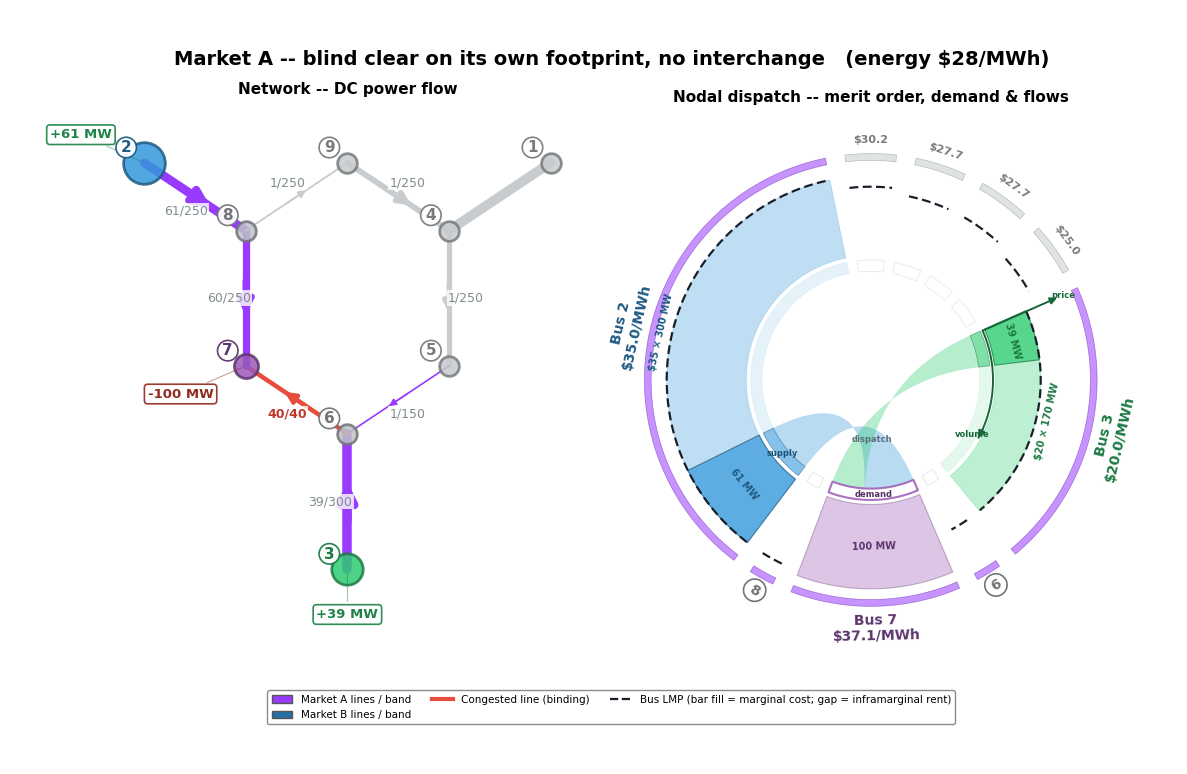

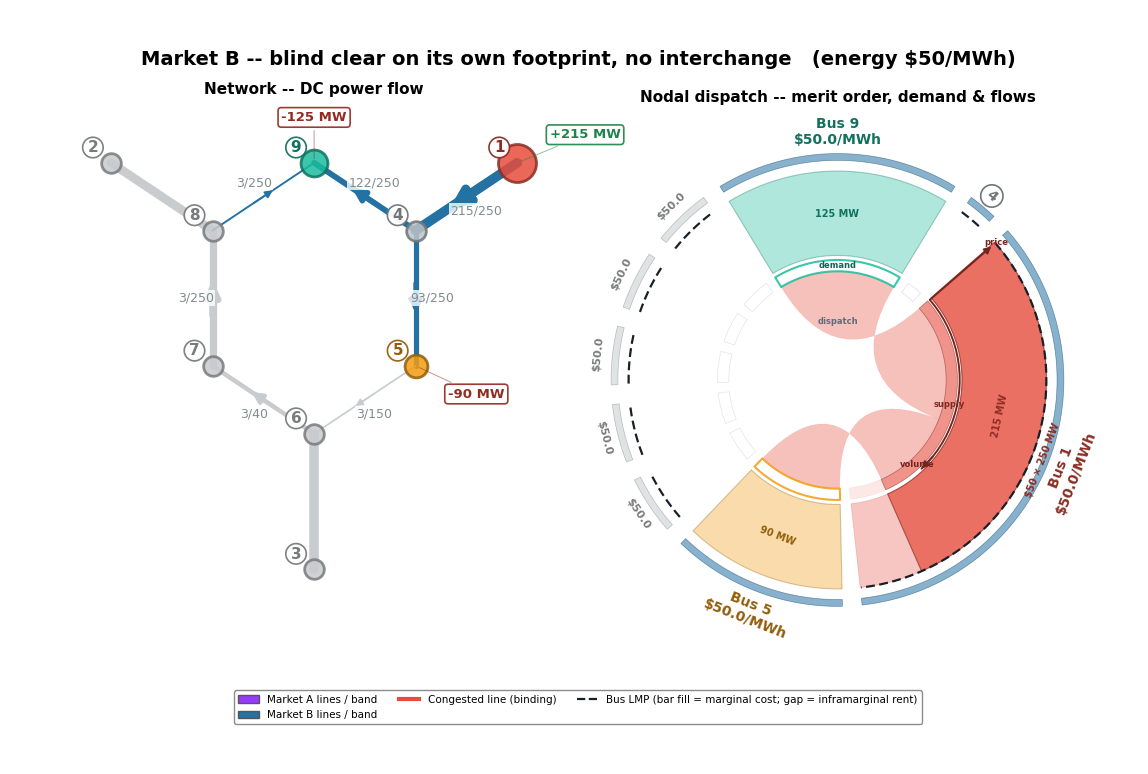

In [8]:
# Each market's blind clear as its own set: the network it dispatches and the
# merit order it prices. Both are internally feasible -- that is the trap.
for eng, r in ((A, rA), (B, rB)):
    market_figure(net, pt, eng, r,
        suptitle=f'{eng.name} -- blind clear on its own footprint, no interchange   '
                 f'(energy ${r.energy_price:.0f}/MWh)')
    plt.show()

In [9]:
ovl = pf[pf.overload]
if len(ovl):
    for ln, row in ovl.iterrows():
        a, b = row['F[Market A]'], row['F[Market B]']
        frm, to, rate, load = row['from'], row['to'], row['rating'], row['loading_%']
        print(f'[!] {ln} ({frm}-{to}): superposed |{row["F^s"]:.1f}| > {rate:.0f} MW rating ({load:.0f}%)')
        print(f'    Market A sees only {a:+.1f} MW, Market B sees only {b:+.1f} MW -- both within {rate:.0f}, '
              f'neither enforces the real limit.')
else:
    print('No overload at these settings -- tighten LINE_RATINGS.')

[!] line_4 (6-7): superposed |43.4| > 40 MW rating (109%)
    Market A sees only +40.0 MW, Market B sees only +3.4 MW -- both within 40, neither enforces the real limit.


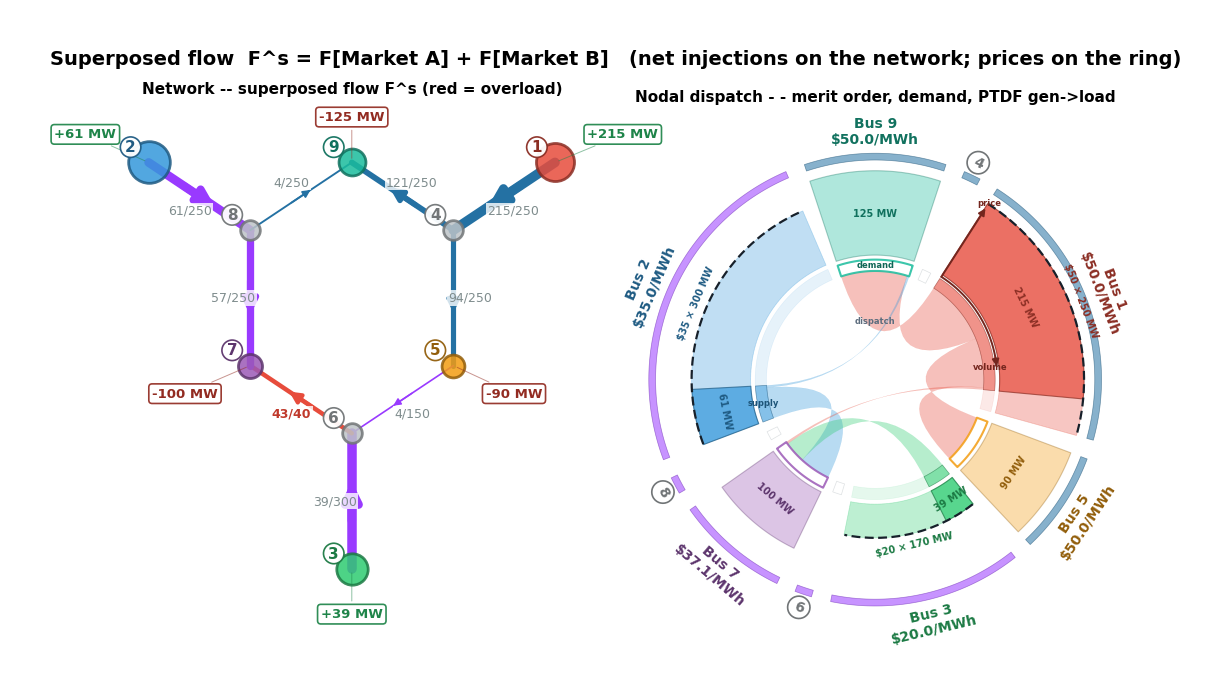

In [10]:
# Visual: the physical superposition as the COMBINED view -- both books' gens
# and loads on one dispatch ring, the network panel annotated with net
# injections (+) and withdrawals (-); prices read off the ring.
sup, dem = {}, {}
for eng, r in [(A, rA), (B, rB)]:
    s, d = to_supply_demand(eng, r); sup.update(s); dem.update(d)
# host LMP for the ring (host = the market that owns the bus)
host_lmp = {}
for r, eng in [(rA, A), (rB, B)]:
    for b in eng.buses: host_lmp[b] = r.lmp[b]
phys = {l: pf.loc[l, 'F^s'] for l in pt.lines}
overloaded = set(pf[pf.overload].index)
fig, _ = plot_combined_letter(
    net, sup, dem,
    bus_colors=dict(BUS_COLORS), bus_lmps=host_lmp,
    bus_net_mw={b: float(rA.injection[pt.bus_idx[b]] + rB.injection[pt.bus_idx[b]])
                for b in pt.buses},
    network_show_lmp=False,
    line_flows=phys, line_widths=susceptance_widths(pt),
    line_colors=market_line_colors(pt), constrained_lines=overloaded,
    flows=nodal_plot.compute_ptdf_flows(net, sup, dem),
    lmp_line=True, bus_groups=MKT_GROUPS, group_colors=dict(MARKET_COLORS),
    show_group_labels=False,
    all_buses=pt.buses, sector_order=RING_ORDER, bus_coords=COORDS, center_bus=CENTER_BUS,
    annotate_roles=True, axis_key=True,
    title_left='Network -- superposed flow F^s (red = overload)',
    suptitle='Superposed flow  F^s = F[Market A] + F[Market B]   (net injections on the network; prices on the ring)')
plt.show()

*In words.* Market A's clear and Market B's clear both returned feasible,
within-limits solutions, with no interchange scheduled between them. Yet
`line_4` (6-7) carries ~43 MW on a 40 MW line, because each market counted only
its own injections (eq. 2) and treated the other's flow as zero. A few MW of
unseen through-flow is all it takes once a line runs near its limit. No
market-to-market reconciliation is running here, so nothing reconciles the two
dispatches before the line does.

## 4. Under-accommodation — day-ahead to real-time congestion uplift/offset

The blind clear of Section 3 left the transmission element overloaded. The host
discovers the constraint after commitment and relieves it in real time. That one
hour carries two different arithmetics, and this section runs both.

The first is a **production cost** — the fuel and the premium the host burns to
bring the flow back inside the rating. The second is a **settlement** — what the
markets collect from load and pay to generation, at two sets of prices and over
two different quantities. They do not match. The gap is the uplift the section
title names.

### The relief, and what it costs to produce

This worked example considers the cost to the market with the monitored
element of accommodating the neighbour's flows to relieve an overload caused by
under-accommodation. The host re-clears (1) with the neighbour's realized
flows fixed on its transmission elements and the premium menu:

$$\min_{g^{\downarrow},\,g^{\uparrow}}\ \sum_{i\in\mathcal R^{M}}\Big[c_i\,g^{\downarrow}_i + (1+\pi)\,c_i\,g^{\uparrow}_i\Big] \quad\text{s.t.}\quad \text{balance},\qquad -\bar F_m \le F^{M}_m + F^{M'}_m \le \bar F_m,\ \ m\in\mathcal M^{M}_{\text{act}}, \tag{5}$$

*In words.* The host minimizes the cost of its day-ahead blocks re-dispatched
at their offer, $c_i\,g^{\downarrow}_i$, plus its increments above the
day-ahead schedule at the premium, $(1+\pi)\,c_i\,g^{\uparrow}_i$ — subject
to its power balance, and to its own flow $F^{M}_m$ **plus** the neighbour's
realized flow $F^{M'}_m$ staying within the rating $\bar F_m$ on each
activated line. The neighbour's flows enter as constants: in real time they
are facts on the transmission elements, not variables.

Here $g^{\downarrow}_i \le \hat g_i$ re-offers the day-ahead schedule
$\hat g_i$ at cost and $g^{\uparrow}_i$ is the increment above it at the
premium $\pi$. The **real-time bill** is the premium actually paid,

$$\Delta C^{\mathrm{RT}} \;=\; C^{\mathrm{RT}} - C^{\mathrm{DA}}, \tag{6}$$

*In words.* The real-time bill $\Delta C^{\mathrm{RT}}$ is the real-time
clearing's cost $C^{\mathrm{RT}}$ minus the day-ahead cost $C^{\mathrm{DA}}$
— the premium actually paid for discovering the constraint after commitment.

And note what (5) makes the host do: it relieves the **whole** exceedance —
$|F^M_m + F^{M'}_m| \le \bar F_m$ — although its own component caused only part
of the loading. The neighbour's share rides free. What that free
ride is worth at the real-time price, and who ends up funding it, is the second
arithmetic below.


In [11]:
# -- EDIT -- the real-time relief menu ---------------------------------------
RT_PREMIUM = 0.5      # pi: increments above the day-ahead schedule cost c*(1+pi)
# -----------------------------------------------------------------------------
def rt_relief(pt_, eng, r_da, nbr_flows, premium=None):
    """Real-time re-clear of `eng` per eq. (5): day-ahead blocks re-offered at
    cost (decrements buy back at the offer), increments at a premium, and the
    neighbour's realized flows fixed on the engine's monitored lines."""
    premium = RT_PREMIUM if premium is None else premium
    gens = {}
    for g, s in eng.gens.items():
        da = float(r_da.dispatch.get(g, 0.0))
        if da > 1e-9:
            gens[f'{g}__da'] = {'bus': s['bus'], 'cost': s['cost'], 'p_nom': da}
        rem = float(s['p_nom']) - da
        if rem > 1e-9:
            gens[f'{g}__inc'] = {'bus': s['bus'], 'cost': s['cost'] * (1.0 + premium), 'p_nom': rem}
    act = list(eng.activated_lines) if eng.activated_lines != 'all' else 'all'
    eng_rt = MarketEngine(name=eng.name, gens=gens, loads=dict(eng.loads),
                          activated_lines=act)      # same name: tables/figures line up
    mon = act if act != 'all' else list(pt_.lines)
    offs = {l: float(nbr_flows.get(l, 0.0)) for l in mon}
    r_rt = solve_engine_dispatch(pt_, eng_rt, flow_offsets=offs, shed_price=150.0)
    return eng_rt, r_rt

# The host is Market A (the overloaded line_4 is in its monitored set).
eng_rtA, r_rtA = rt_relief(pt, A, rA, rB.flow_own)

# Redispatch summary: final bus dispatch vs the day-ahead schedule.
da_by_bus = dict(rA.gen_by_bus)
rt_by_bus = dict(r_rtA.gen_by_bus)
moves = {b: rt_by_bus.get(b, 0.0) - da_by_bus.get(b, 0.0)
         for b in set(da_by_bus) | set(rt_by_bus)}
print('real-time redispatch (MW by bus, vs day-ahead):',
      {b: round(v, 1) for b, v in moves.items() if abs(v) > 1e-6})
print(f'shed: {sum(r_rtA.shed_by_bus.values()):.1f} MW' if r_rtA.shed_by_bus else 'shed: none')

# Feasibility restored?
pf_rt = physical_flows(pt, [r_rtA, rB])
print('overloads after real-time relief:', pf_rt[pf_rt.overload].index.tolist() or 'none')
print()
dC_rt = r_rtA.total_cost - rA.total_cost
rows = [
    {'arrangement': 'blind clears (Section 3)',
     'Market A cost': round(rA.total_cost), 'Market B cost': round(rB.total_cost),
     'sum': round(rA.total_cost + rB.total_cost), 'line within limits': 'NO -- line_4 overloaded'},
    {'arrangement': f'blind + real-time relief (pi={RT_PREMIUM:.2f})',
     'Market A cost': round(r_rtA.total_cost), 'Market B cost': round(rB.total_cost),
     'sum': round(r_rtA.total_cost + rB.total_cost), 'line within limits': 'yes -- relieved after the fact'},
]
print(f'the real-time bill  Delta C_RT = {dC_rt:,.0f} $/h  (eq. 6) -- paid entirely by the host')
pd.DataFrame(rows).set_index('arrangement')


real-time redispatch (MW by bus, vs day-ahead): {'3': np.float64(-4.6), '2': np.float64(4.6)}
shed: none
overloads after real-time relief: none

the real-time bill  Delta C_RT = 150 $/h  (eq. 6) -- paid entirely by the host


,Market A cost,Market B cost,sum,line within limits
arrangement,,,,
blind clears (Section 3),2909,10750,13659,NO -- line_4 overloaded
blind + real-time relief (pi=0.50),3059,10750,13809,yes -- relieved after the fact


*In words.* The relief works — the line comes back inside its rating — but
look at who does what. Market A backs its cheap delivery down and covers the
energy from its dearer unit at the real-time premium, relieving an exceedance
of which its own component was only part; Market B's few MW of loop flow ride
through unchanged, unpriced, and unpaid-for. The real-time bill $\Delta
C^{\mathrm{RT}}$ is the deterministic price of under-accommodation: discover
the constraint after commitment, and the relief comes from the premium menu.
Section 5 prices the opposite instinct — pay ex ante instead, in withheld
capability.


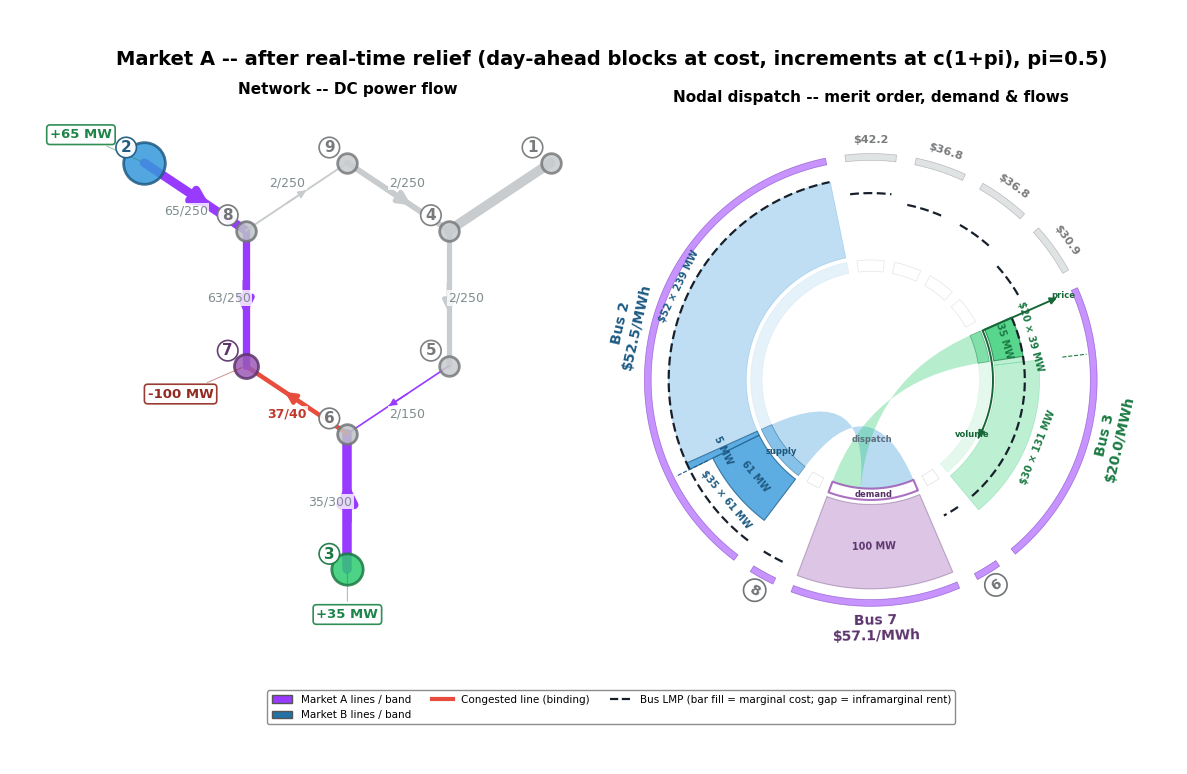

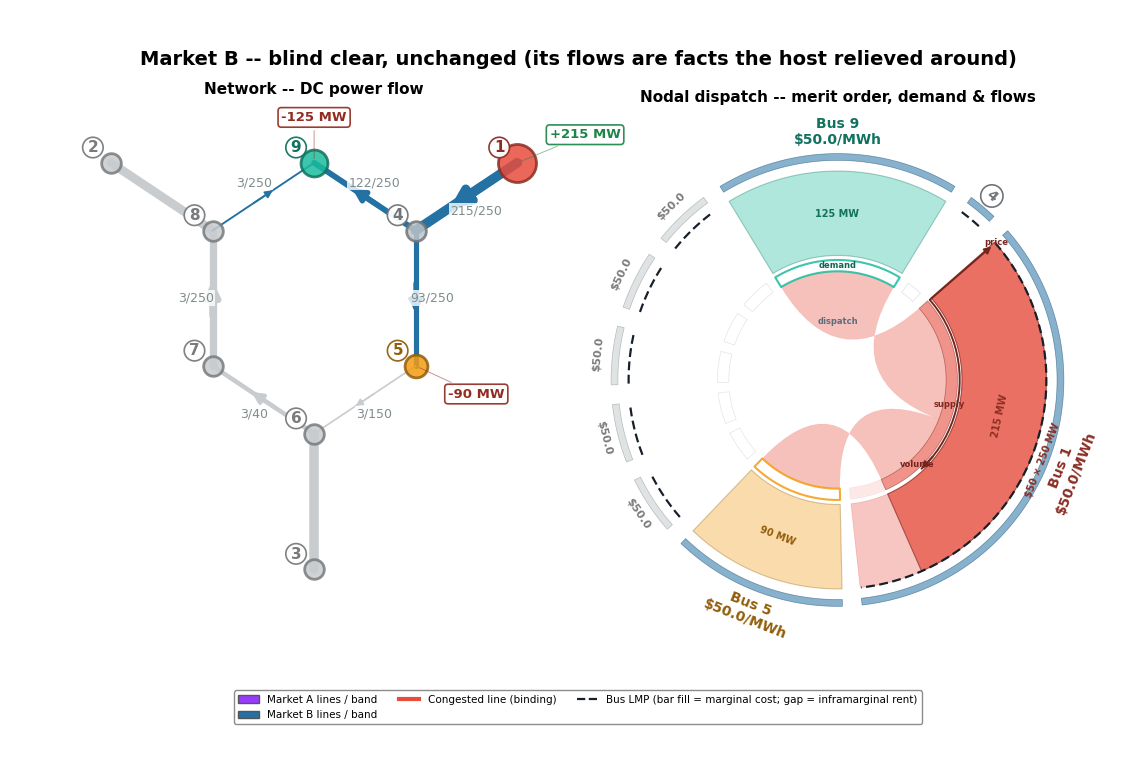

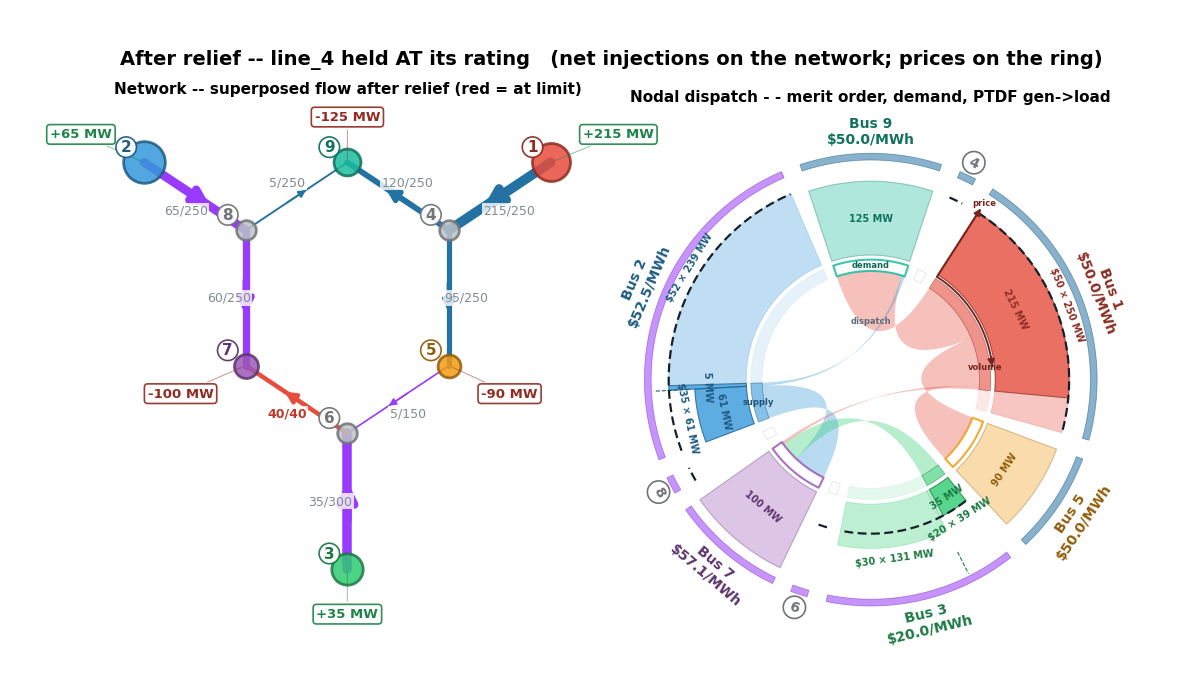

In [12]:
# The relieved day in three frames: each market's clearing, then the one line.
market_figure(net, pt, eng_rtA, r_rtA,
    suptitle=f'Market A -- after real-time relief (day-ahead blocks at cost, increments at c(1+pi), pi={RT_PREMIUM})')
plt.show()
market_figure(net, pt, B, rB,
    suptitle='Market B -- blind clear, unchanged (its flows are facts the host relieved around)')
plt.show()

sup4, dem4 = {}, {}
for _e, _r in ((eng_rtA, r_rtA), (B, rB)):
    _s, _d = to_supply_demand(_e, _r); sup4.update(_s); dem4.update(_d)
pf4 = physical_flows(pt, [r_rtA, rB]).rename(columns={'F_phys': 'F^s'})
phys4 = {l: float(pf4.loc[l, 'F^s']) for l in pt.lines}
host_lmp4 = {b: (r_rtA if mkt_of(b) == 'Market A' else rB).lmp[b] for b in pt.buses}
at_limit4 = {l for l in pt.lines if abs(phys4[l]) >= pt.s_nom[pt.line_idx[l]] - 1e-3}
fig, _ = plot_combined_letter(
    net, sup4, dem4,
    bus_colors=dict(BUS_COLORS), bus_lmps=host_lmp4,
    bus_net_mw={b: float(r_rtA.injection[pt.bus_idx[b]] + rB.injection[pt.bus_idx[b]])
                for b in pt.buses},
    network_show_lmp=False,
    line_flows=phys4, line_widths=susceptance_widths(pt),
    line_colors=market_line_colors(pt), constrained_lines=at_limit4,
    flows=nodal_plot.compute_ptdf_flows(net, sup4, dem4),
    lmp_line=True, bus_groups=MKT_GROUPS, group_colors=dict(MARKET_COLORS),
    show_group_labels=False,
    all_buses=pt.buses, sector_order=RING_ORDER, bus_coords=COORDS, center_bus=CENTER_BUS,
    annotate_roles=True, axis_key=True,
    title_left='Network -- superposed flow after relief (red = at limit)',
    suptitle='After relief -- line_4 held AT its rating   (net injections on the network; prices on the ring)')
plt.show()

*In words.* Three frames of the same relieved hour: Market A's clearing on the
real-time menu (its day-ahead blocks re-offered at cost, its increments at the
premium), Market B's blind clear exactly as it was — its flows are the facts
the host relieved around — and the one line carrying their superposition, with
line_4 held at its rating by the host's redispatch alone.


### The two settlements, and the volume that carries the rent

Equations (5) and (6) priced the relief in fuel. The settlement runs over
different quantities at different prices, and it does not balance. A
two-settlement market pays each resource its day-ahead schedule at day-ahead
prices and its deviation from that schedule at real-time prices,

$$\Pi_i \;=\; \lambda^{\mathrm{DA}}_{n(i)}\,\hat g_i \;+\; \lambda^{\mathrm{RT}}_{n(i)}\,\big(g^{\mathrm{RT}}_i-\hat g_i\big). \tag{7}$$

*In words.* Resource $i$'s payment $\Pi_i$ is its day-ahead schedule $\hat g_i$
valued at the day-ahead nodal price $\lambda^{\mathrm{DA}}_{n(i)}$ at its bus,
plus its deviation from that schedule, $g^{\mathrm{RT}}_i-\hat g_i$, valued at
the real-time nodal price $\lambda^{\mathrm{RT}}_{n(i)}$ at the same bus.

**The settlement base is the schedule in the day-ahead and the deviation in real
time.** The market operator's net position in a settlement is what load pays
less what generation is paid, at that settlement's prices and over that
settlement's quantities,

$$R^{\mathrm{DA}}=\sum_{n\in\mathcal N}\lambda^{\mathrm{DA}}_n\big(d_n-\hat g_{(n)}\big),\qquad R^{\mathrm{RT}}=\sum_{n\in\mathcal N}\lambda^{\mathrm{RT}}_n\big(\Delta d_n-\Delta g_{(n)}\big). \tag{8}$$

*In words.* The day-ahead net position $R^{\mathrm{DA}}$ sums, over every bus
$n$, the day-ahead nodal price $\lambda^{\mathrm{DA}}_n$ times the load $d_n$
less the scheduled generation $\hat g_{(n)}$ at that bus; the real-time net
position $R^{\mathrm{RT}}$ sums the real-time nodal price
$\lambda^{\mathrm{RT}}_n$ times the load deviation $\Delta d_n$ less the
generation deviation $\Delta g_{(n)}$ at that bus.

On a lossless network settled at nodal prices $R^{\mathrm{DA}}$ is the
day-ahead congestion rent: it equals $\sum_m|\mu^{\mathrm{DA}}_m F_m|$ over the
binding lines, and it is the pool a market with congestion rights pays those
rights out of. The host's load does not deviate in this example,
$\Delta d_n = 0$, so $R^{\mathrm{RT}}$ runs over the redispatch alone.

**A constraint discovered after the day-ahead does not become less valuable.**
Here it becomes more valuable, because the neighbour's flow arrived. But the
quantity the real-time settlement runs over is the deviation, not the schedule.

Substituting the two clearings' limits into (8) says exactly what that quantity
is. The host enforced $\bar F_m$ on its own flow in the day-ahead and, once the
neighbour's flow is a fact, $\bar F_m - F^{M'}_m$ in real time. Writing
$\widehat F^{M'}_m$ for whatever the day-ahead reserved (zero when it clears
blind, as in this section) and taking the day-ahead schedule to use the room it
was given,

$$R^{\mathrm{RT}}=\sum_{m}\mu^{\mathrm{RT}}_m\Big[\underbrace{(\bar F_m-F^{M'}_m)}_{\text{real-time limit}}-\underbrace{(\bar F_m-\widehat F^{M'}_m)}_{\text{day-ahead limit}}\Big]=-\sum_{m}\mu^{\mathrm{RT}}_m\big(F^{M'}_m-\widehat F^{M'}_m\big). \tag{9}$$

*In words.* The real-time net position $R^{\mathrm{RT}}$ sums, over the
constrained lines $m$, the real-time shadow price $\mu^{\mathrm{RT}}_m$ times the
difference between the real-time limit $\bar F_m - F^{M'}_m$ and the day-ahead
limit $\bar F_m - \widehat F^{M'}_m$; that difference is minus the error in the
reservation, $F^{M'}_m - \widehat F^{M'}_m$.

**So the volume that carries the real-time rent is not a quantity of energy — it
is the room the day-ahead schedule left on the real-time limit.** Read the last
form: the real-time settlement is minus the real-time shadow price times the
error in what the day-ahead reserved for the neighbour. Reserve nothing and the
whole neighbour flow is the error, which is this section; reserve too much and
the sign flips, which is Section 5. The reservation $\widehat F^{M'}_m$ that
Section 5 sets ex ante is the same term this settlement is measured against.


In [13]:
# The relieved hour read as two settlements (eqs. 7-8): what each one prices,
# over what quantity, and what the operator collects on it.
HOST  = 'Market A'
CLINE = ovl.index[0] if len(ovl) else 'line_4'    # the line Section 3 overloaded
hb    = MKT_DEFS[HOST]                            # the host's buses
hl    = {b: LOADS[b] for b in hb if b in LOADS}   # the host's load -- unchanged in real time

def settlement_net(res, gen_by_bus, load_by_bus):
    """Eq. (8) at one clearing's prices: paid by load, paid to generation, and the
    operator's net position -- the congestion rent when the network is lossless."""
    pay = sum(res.lmp[b] * float(load_by_bus.get(b, 0.0)) for b in hb)
    rev = sum(res.lmp[b] * float(gen_by_bus.get(b, 0.0)) for b in hb)
    return pay, rev, pay - rev

g_da = {b: rA.gen_by_bus.get(b, 0.0)    for b in hb}
g_rt = {b: r_rtA.gen_by_bus.get(b, 0.0) for b in hb}
dev  = {b: g_rt[b] - g_da[b] for b in hb}         # the real-time deviation
dev_mw = sum(abs(v) for v in dev.values()) / 2.0  # MW re-dispatched

_, _, R_DA = settlement_net(rA,    g_da, hl)
_, _, R_RT = settlement_net(r_rtA, dev,  {})      # nothing on the load side deviates
muDA, muRT = rA.line_dual[CLINE], r_rtA.line_dual[CLINE]

print(f'day-ahead net position  R_DA = {R_DA:9,.1f} $/h   = sum |mu*F| over the binding lines'
      f' = {sum(abs(rA.line_dual[l] * rA.flow_own[l]) for l in ACTIVATED_LINES[HOST]):,.1f}')
print(f'real-time net position  R_RT = {R_RT:9,.1f} $/h   '
      f"({'collected' if R_RT > 0 else 'PAID OUT -- recovered from load as uplift'})")
print()
pd.DataFrame([
    {'settlement': 'day-ahead (eq. 7, first term)',
     'what it settles': f'the schedule -- {sum(hl.values()):.0f} MW of load',
     f'{CLINE} shadow price ($/MWh)': round(abs(muDA), 2),
     'settlement base (MW)': round(sum(hl.values()), 1),
     'operator net ($/h)': round(R_DA, 1)},
    {'settlement': 'real time (eq. 7, second term)',
     'what it settles': f'the deviation -- {dev_mw:.1f} MW of redispatch',
     f'{CLINE} shadow price ($/MWh)': round(abs(muRT), 2),
     'settlement base (MW)': round(dev_mw, 1),
     'operator net ($/h)': round(R_RT, 1)},
]).set_index('settlement')

day-ahead net position  R_DA =     804.1 $/h   = sum |mu*F| over the binding lines = 804.1
real-time net position  R_RT =    -150.0 $/h   (PAID OUT -- recovered from load as uplift)



,what it settles,line_4 shadow price ($/MWh),settlement base (MW),operator net ($/h)
settlement,,,,
"day-ahead (eq. 7, first term)",the schedule -- 100 MW of load,20.10,100.0,804.1
"real time (eq. 7, second term)",the deviation -- 4.6 MW of redispatch,43.56,4.6,-150.0


In [14]:
# Where the real-time value of the constrained line sits, and who settles it.
FA_rt, FB = r_rtA.flow_own[CLINE], rB.flow_own[CLINE]
display(pd.DataFrame([
    {f'flow on {CLINE}': 'the whole line', 'MW': round(FA_rt + FB, 1),
     'settled in': '--', 'value at |mu_RT| ($/h)': round(abs(muRT) * (FA_rt + FB), 1)},
    {f'flow on {CLINE}': "the host's own component", 'MW': round(FA_rt, 1),
     'settled in': f'{HOST}: schedule at DA prices, deviation at RT prices',
     'value at |mu_RT| ($/h)': round(abs(muRT) * FA_rt, 1)},
    {f'flow on {CLINE}': "the neighbour's component", 'MW': round(FB, 1),
     'settled in': 'neither market',
     'value at |mu_RT| ($/h)': round(abs(muRT) * FB, 1)},
]).set_index(f'flow on {CLINE}'))

dC = r_rtA.total_cost - rA.total_cost
print(f'\nhost redispatch cost                          Delta C_RT = {dC:8,.2f} $/h  (eq. 6)')
print(f"neighbour's flow at the host's real-time price  |mu_RT|*F^B = {abs(muRT) * FB:8,.2f} $/h")
print(f'difference                                                 = {dC - abs(muRT) * FB:8.2e} $/h')
# eq. (9): the real-time net position is minus the shadow price times the error in
# what the day-ahead reserved for the neighbour. This section reserves nothing.
F_hat_B = 0.0                       # the blind day-ahead reserved no room (Section 5 does)
print(f'\neq. (9)  -mu_RT * (F^B - F^B_hat) = {-abs(muRT) * (FB - F_hat_B):8,.2f} $/h'
      f'   vs R_RT from eq. (8) = {R_RT:8,.2f} $/h')

print(f'\n{HOST} collected {R_DA:,.0f} $/h of congestion rent in the day-ahead and paid out'
      f' {abs(R_RT):,.0f} $/h in real time,\nagainst a constraint worth'
      f' {abs(muRT) * (FA_rt + FB):,.0f} $/h on the line at the real-time price.')

,MW,settled in,value at |mu_RT| ($/h)
flow on line_4,,,
the whole line,40.0,--,1742.2
the host's own component,36.6,"Market A: schedule at DA prices, deviation at ...",1592.2
the neighbour's component,3.4,neither market,150.0



host redispatch cost                          Delta C_RT =   150.02 $/h  (eq. 6)
neighbour's flow at the host's real-time price  |mu_RT|*F^B =   150.02 $/h
difference                                                 = 0.00e+00 $/h

eq. (9)  -mu_RT * (F^B - F^B_hat) =  -150.02 $/h   vs R_RT from eq. (8) =  -150.02 $/h

Market A collected 804 $/h of congestion rent in the day-ahead and paid out 150 $/h in real time,
against a constraint worth 1,742 $/h on the line at the real-time price.


*In words.* The shadow price on the constrained line more than doubles from the
day-ahead to real time, while what settles against it in real time is the
redispatch — here a few MW against the whole scheduled load. By eq. (9) the
figure that matters is the reservation error, and with nothing reserved that is
the neighbour's entire flow. The day-ahead settlement collects a congestion
rent; the real-time settlement pays one out, because on a balanced redispatch
the energy components net to zero and what is left is the operator buying the
relief. A market with congestion rights funds them from the first number and
recovers the second from load. Each market has a name for that second number:
in this ISO's settlement it is the **real-time congestion offset**, charged to
measured demand; PJM calls the same residual **balancing congestion**.

## 5. Over-accommodation — the ex-ante reservation

If Market B's flows cross Market A's transmission elements, Market A can defend its limits by
**reserving room** for them: enforce each line it monitors not at its full rating,
but at the rating minus the flow it expects the other market to put there. This
is how Available Transfer Capability (ATC) methodologies work — transfer
capability is released to a market only after subtracting expected loop flow
plus a reliability margin.

The reservation restores feasibility, and that is its purpose. The cost is that
the reserved room is **exogenous**: it is fixed before the clear, sized from a
forecast of the other market's dispatch, and padded with a conservatism margin.
Reserve too little and the line still overloads; reserve too much and
capability that the unified clearing would use sits idle.

### The reservation and the effective limit

**Each market enforces its limits with the other's expected flow already on the line.**

$$-\bar F_m\le F^M_m+\widehat F^{M'}_m\le \bar F_m\qquad \forall\,m\in\mathcal M^M_{\mathrm{act}}. \qquad\qquad(10)$$

*In words.* Market $M$ checks each of its own lines against its own flow plus a fixed
estimate $\widehat F^{M'}_m$ of the other market's flow on that line. The estimate enters the
optimisation as a constant, not a decision variable (`flow_offsets`). The
reservation is made on the lines $M$ activates —
$\mathcal M^M_{\mathrm{act}}$ from Section 2 — and $M'$ is the other market in
$\mathcal E$.

**The reservation is a reference flow times a margin.**

$$\widehat F^{M'}_m=\beta\,F^{M',\mathrm{ref}}_m\qquad (m\in\mathcal M^M_{\mathrm{act}}),\qquad \beta\ge 1. \qquad\qquad(11)$$

*In words.* The reference flow $F^{M',\mathrm{ref}}_m$ here is the other footprint's per-line
component in the unified clearing — the best available estimate of how the other market uses
the line. The margin $\beta$ is the ATC-style conservatism: it protects against the
estimate being wrong, and its cost is capability withheld from the market.

In [15]:
# -- EDIT -- the reservation each market makes for the other's flows --------
ATC_MARGIN = 1.25    # beta: 1.0 = reserve exactly the reference flow
# ---------------------------------------------------------------------------

# Reference flow: each footprint's per-line component in the UNIFIED clearing.
uni_cong  = MarketEngine(name='unified', gens={g: dict(s) for g, s in GEN_FLEET.items()},
                         loads=dict(LOADS), activated_lines='all')
runi_cong = solve_engine_dispatch(pt, uni_cong)
comp = {}
for m, buses in MKT_DEFS.items():
    p = np.zeros(pt.n_bus)
    for i, b in enumerate(pt.buses):
        if b in buses: p[i] = runi_cong.injection[i]
    comp[m] = pt.ptdf @ p

# The reservations: {line: signed MW} on each market's monitored lines.
# These are plain dicts -- override any entry to refine the rule.
ACCOMMODATION_A = {l: round(float(comp['Market B'][pt.line_idx[l]]) * ATC_MARGIN, 1)
                   for l in ACTIVATED_LINES['Market A']}
ACCOMMODATION_B = {l: round(float(comp['Market A'][pt.line_idx[l]]) * ATC_MARGIN, 1)
                   for l in ACTIVATED_LINES['Market B']}
print('Market A reserves (signed MW):', ACCOMMODATION_A)
print('Market B reserves (signed MW):', ACCOMMODATION_B)
print()

rA_acc = solve_engine_dispatch(pt, A, flow_offsets=ACCOMMODATION_A)
rB_acc = solve_engine_dispatch(pt, B, flow_offsets=ACCOMMODATION_B)
pf_acc = physical_flows(pt, [rA_acc, rB_acc])
print('overloads after accommodation:', pf_acc[pf_acc.overload].index.tolist() or 'none')
print()

rows = [
    {'arrangement': 'blind clears (issue 1)',
     'Market A cost': round(rA.total_cost), 'Market B cost': round(rB.total_cost),
     'sum': round(rA.total_cost + rB.total_cost), 'line within limits': 'NO -- line_4 overloaded'},
    {'arrangement': f'accommodated (beta={ATC_MARGIN})',
     'Market A cost': round(rA_acc.total_cost), 'Market B cost': round(rB_acc.total_cost),
     'sum': round(rA_acc.total_cost + rB_acc.total_cost), 'line within limits': 'yes'},
    {'arrangement': 'unified clearing',
     'Market A cost': '--', 'Market B cost': '--',
     'sum': round(runi_cong.total_cost), 'line within limits': 'yes'},
]
pd.DataFrame(rows).set_index('arrangement')

Market A reserves (signed MW): {'line_2': 4.3, 'line_3': -0.0, 'line_4': 4.3, 'line_5': 4.3, 'line_6': 0.0}
Market B reserves (signed MW): {'line_0': -268.8, 'line_1': -128.0, 'line_7': 140.8, 'line_8': 140.8}

overloads after accommodation: none



,Market A cost,Market B cost,sum,line within limits
arrangement,,,,
blind clears (issue 1),2909,10750,13659,NO -- line_4 overloaded
accommodated (beta=1.25),2995,10750,13745,yes
unified clearing,--,--,8941,yes


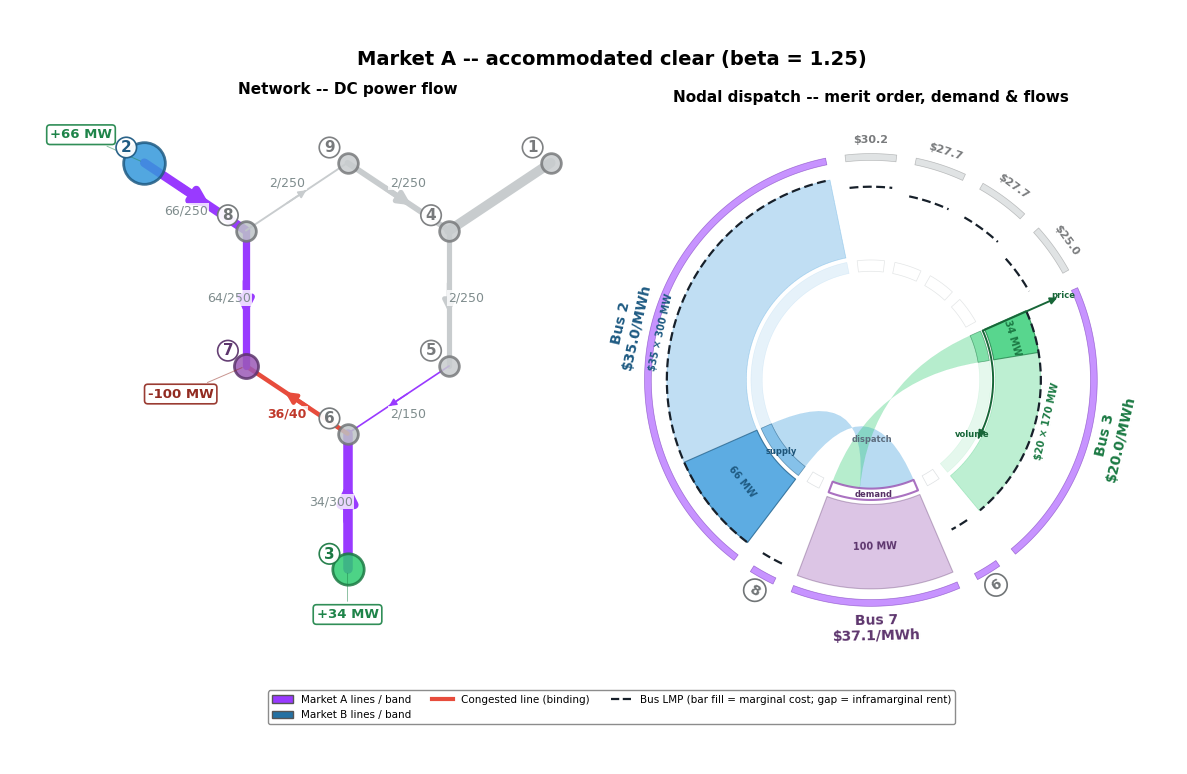

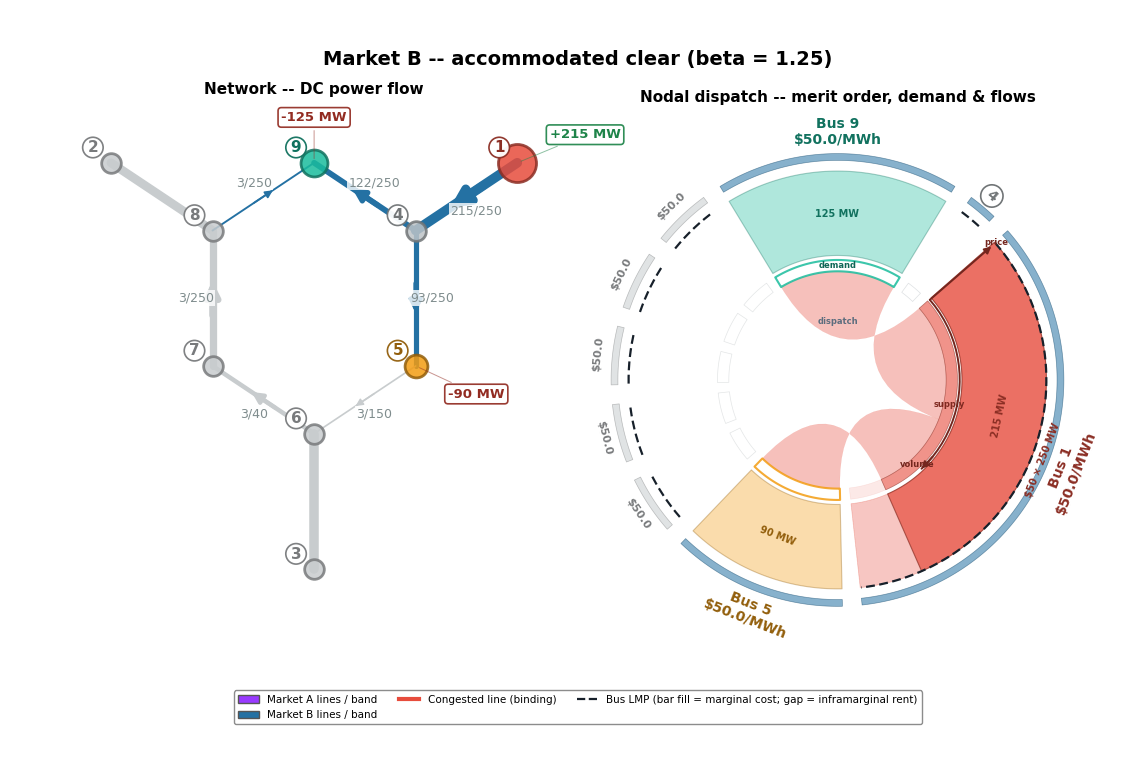

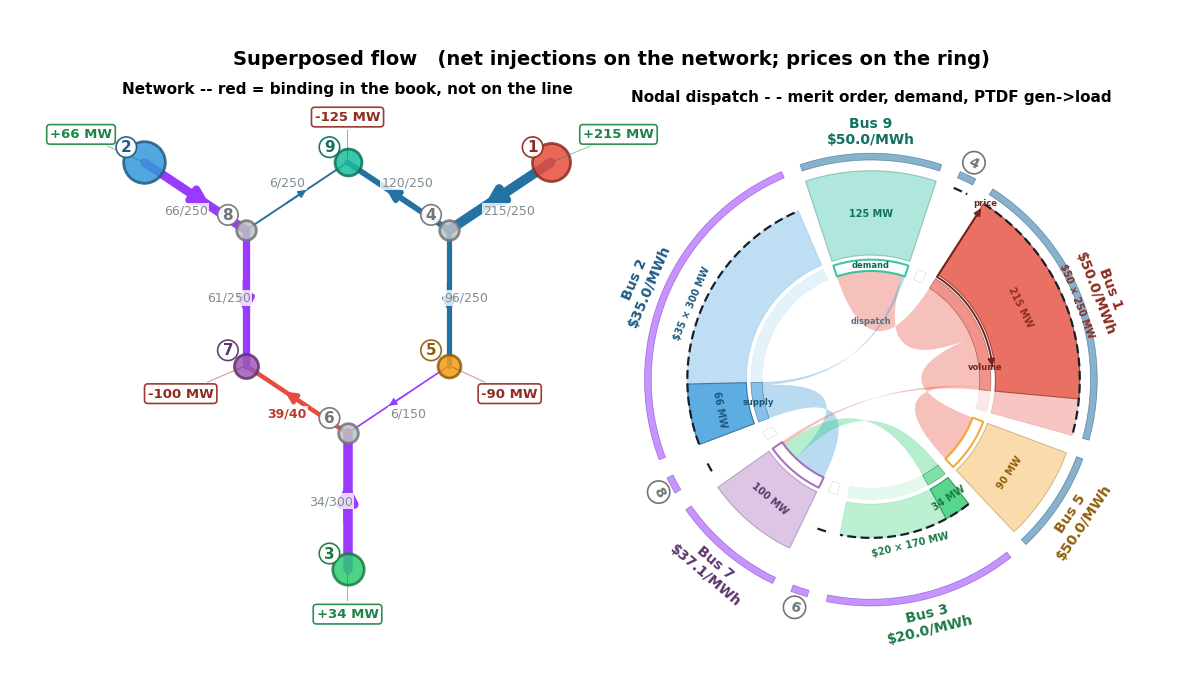

A's book enforces F^A + reservation = 40.0 MW on line_4 (binding, mu = -20.10 $/MWh) while the line actually carries 39.1 MW
-> PHANTOM CONGESTION: 0.9 MW of physical headroom under a binding, priced constraint
-> the phantom margin's bill: 17 $/h over the exact reservation (beta = 1.0)


In [16]:
# The accommodated day in three frames -- and the phantom the margin produces.
for _e, _r in ((A, rA_acc), (B, rB_acc)):
    market_figure(net, pt, _e, _r,
        suptitle=f'{_e.name} -- accommodated clear (beta = {ATC_MARGIN})')
    plt.show()

sup5, dem5 = {}, {}
for _e, _r in ((A, rA_acc), (B, rB_acc)):
    _s, _d = to_supply_demand(_e, _r); sup5.update(_s); dem5.update(_d)
pf5 = physical_flows(pt, [rA_acc, rB_acc]).rename(columns={'F_phys': 'F^s'})
phys5 = {l: float(pf5.loc[l, 'F^s']) for l in pt.lines}
host_lmp5 = {b: (rA_acc if mkt_of(b) == 'Market A' else rB_acc).lmp[b] for b in pt.buses}
enf5 = rA_acc.flow_own['line_4'] + ACCOMMODATION_A['line_4']     # what A's book enforces
act5 = phys5['line_4']                                            # what the line carries
binding5 = {'line_4'} if abs(enf5) >= pt.s_nom[pt.line_idx['line_4']] - 1e-3 else set()
fig, _ = plot_combined_letter(
    net, sup5, dem5,
    bus_colors=dict(BUS_COLORS), bus_lmps=host_lmp5,
    bus_net_mw={b: float(rA_acc.injection[pt.bus_idx[b]] + rB_acc.injection[pt.bus_idx[b]])
                for b in pt.buses},
    network_show_lmp=False,
    line_flows=phys5, line_widths=susceptance_widths(pt),
    line_colors=market_line_colors(pt), constrained_lines=binding5,
    flows=nodal_plot.compute_ptdf_flows(net, sup5, dem5),
    lmp_line=True, bus_groups=MKT_GROUPS, group_colors=dict(MARKET_COLORS),
    show_group_labels=False,
    all_buses=pt.buses, sector_order=RING_ORDER, bus_coords=COORDS, center_bus=CENTER_BUS,
    annotate_roles=True, axis_key=True,
    title_left='Network -- red = binding in the book, not on the line',
    suptitle='Superposed flow   (net injections on the network; prices on the ring)')
plt.show()

# The phantom, priced: the margin binds A's book while the line has headroom.
head5 = pt.s_nom[pt.line_idx['line_4']] - abs(act5)
mu5 = rA_acc.line_dual['line_4']
offA1 = {l: float(comp['Market B'][pt.line_idx[l]]) for l in ACTIVATED_LINES['Market A']}
offB1 = {l: float(comp['Market A'][pt.line_idx[l]]) for l in ACTIVATED_LINES['Market B']}
rA_1 = solve_engine_dispatch(pt, A, flow_offsets=offA1)
rB_1 = solve_engine_dispatch(pt, B, flow_offsets=offB1)
phantom_cost = (rA_acc.total_cost + rB_acc.total_cost) - (rA_1.total_cost + rB_1.total_cost)
print(f"A's book enforces F^A + reservation = {enf5:.1f} MW on line_4 "
      f"(binding, mu = {mu5:.2f} $/MWh) while the line actually carries {act5:.1f} MW")
print(f"-> PHANTOM CONGESTION: {head5:.1f} MW of physical headroom under a binding, priced constraint")
print(f"-> the phantom margin's bill: {phantom_cost:,.0f} $/h over the exact reservation (beta = 1.0)")

*In words.* Three frames of the accommodated hour: each market's clearing with
its reservation folded in, and the one line, drawn red where it is **binding
in the host's book, not physically overloaded**. The margin above the true
flow is congestion that exists only in the representation: the host's
constraint prices at $\mu$ while the line reports headroom, and the cost of the
padding is the difference between the two.


In [17]:
# The price of conservatism: sweep the ATC margin and watch the cost climb.
rows = []
for g in [1.0, 1.25, 1.5, 2.0]:
    offA = {l: float(comp['Market B'][pt.line_idx[l]]) * g for l in ACTIVATED_LINES['Market A']}
    offB = {l: float(comp['Market A'][pt.line_idx[l]]) * g for l in ACTIVATED_LINES['Market B']}
    try:
        ra = solve_engine_dispatch(pt, A, flow_offsets=offA)
        rb = solve_engine_dispatch(pt, B, flow_offsets=offB)
        pfg = physical_flows(pt, [ra, rb])
        rows.append({'margin beta': g, 'sum cost': round(ra.total_cost + rb.total_cost),
                     'overloads': ', '.join(pfg[pfg.overload].index.tolist()) or 'none'})
    except RuntimeError:
        rows.append({'margin beta': g, 'sum cost': None, 'overloads': 'INFEASIBLE'})
lad = pd.DataFrame(rows).set_index('margin beta')
lad['extra vs beta=1.0'] = lad['sum cost'] - lad.loc[1.0, 'sum cost']
lad

,sum cost,overloads,extra vs beta=1.0
margin beta,,,
1.00,13728,none,0
1.25,13745,none,17
1.50,13762,none,34
2.00,13797,none,69


*In words.* The accommodation works: the line is safe, at a combined dispatch
cost a little above the blind clears and far above the unified clearing (the
remaining gap is the unrealised trade, taken up in 205). The margin
ladder prices the conservatism: every notch of $\beta$ moves Market A onto
dearer units to hold room it will almost never need. Notice the size of Market
B's reservations — the unified reference has Market A's generation serving the
whole system, so Market B holds room for flows far larger than anything in its
own dispatch. That withheld capability is what the ladder is measuring. And the reservation is
only as good as its reference flow — it was computed from one snapshot of the
other market's dispatch. Change the loads or schedule an interchange and the
snapshot is stale: the line can overload again with the reservation in place
(try it in the sandbox). Operations diverge from the schedule; a fixed
reservation cannot follow.

## 6. Sandbox

The congestion-management experiment, end to end: choose footprints, monitored and
activated sets, ratings, costs and loads; set the reservation margin and the real-time
premium; the cell clears both books, reserves, checks the superposition, runs
the real-time relief if the reservation under-covers, and reports the bill —
with each market's set and the combined view drawn below. Re-run Section 2 to
restore the defaults.


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


beta = 0.0 -> real-time relief ran on ['line_4'] (pi=0.25)
host cost: DA $2,909/h, final $3,018/h (bill $110/h) | B $10,750/h


,from,to,F[Market A],F[Market B],F^s,rating,loading_%,overload
line,,,,,,,,
line_0,1,4,0.0,215.0,215.0,250.0,86.0,False
line_1,4,5,1.7,93.4,95.2,250.0,38.0,False
line_2,5,6,1.7,3.4,5.2,150.0,3.0,False
line_3,3,6,34.8,-0.0,34.8,300.0,12.0,False
line_4,6,7,36.6,3.4,40.0,40.0,100.0,False
line_5,7,8,-63.4,3.4,-60.0,250.0,24.0,False
line_6,8,2,-65.2,0.0,-65.2,250.0,26.0,False
line_7,8,9,1.7,3.4,5.2,250.0,2.0,False
line_8,9,4,1.7,-121.6,-119.8,250.0,48.0,False


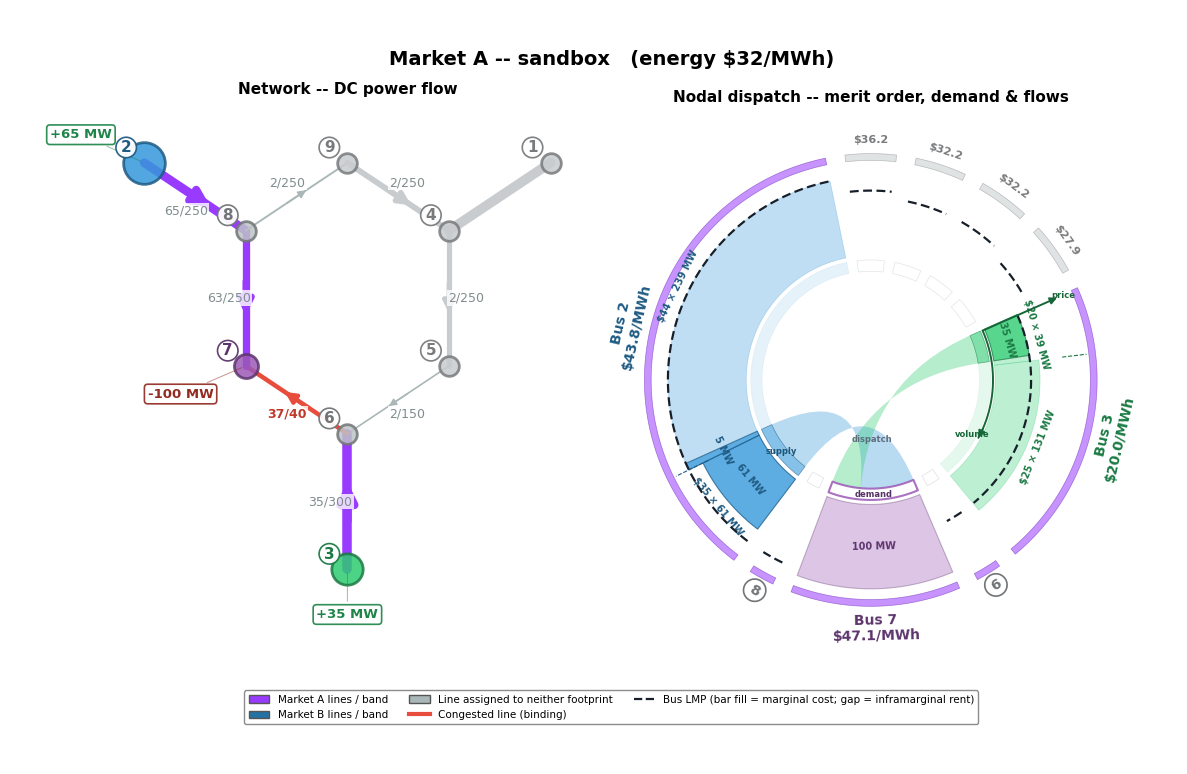

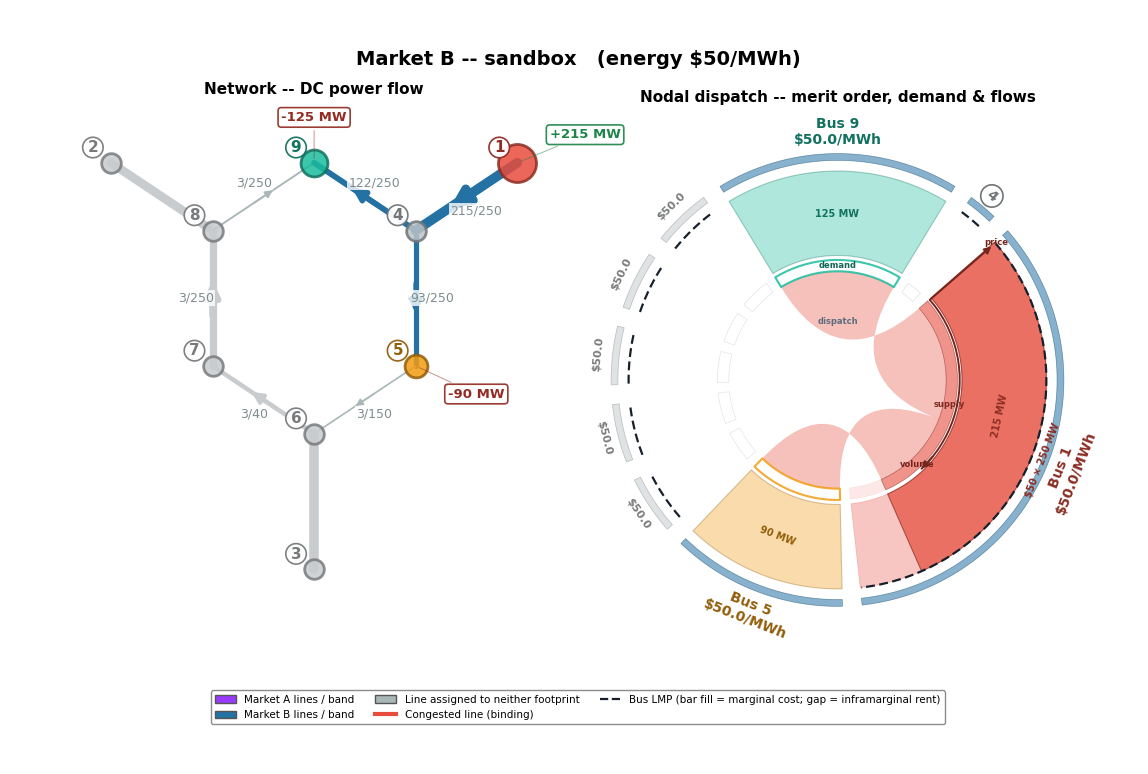

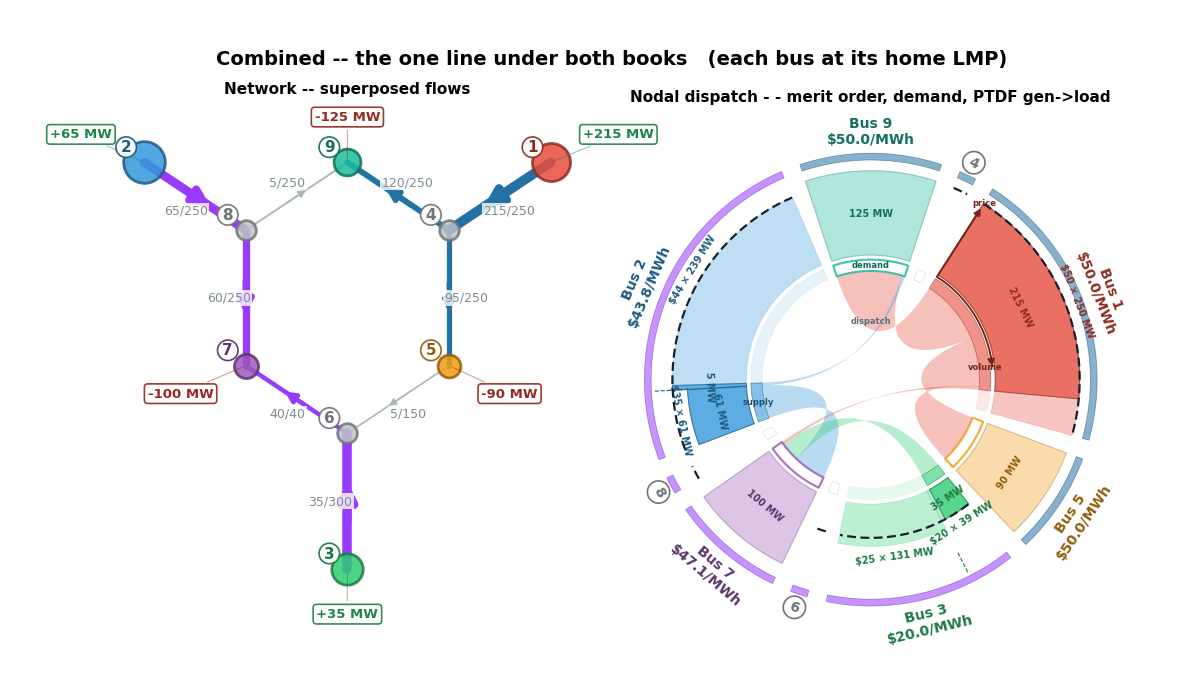

In [18]:
# -- EDIT -- free-form congestion-management experiment ----------------------
RATINGS        = {'line_4': 40.0}
A_BUSES        = ['2', '8', '7', '6', '3']
B_BUSES        = ['1', '9', '4', '5']
COSTS          = {}           # {'gen_1': 30.0}
LOADS_OVERRIDE = {}           # {'9': 160.0}
ACC_MARGIN     = 0.0          # beta: 0 = blind; 1.0 = reserve the forecast exactly
RT_PREMIUM_X   = 0.25         # pi for the relief step
# ------------------------------------------------------------------------------
net = build_network(RATINGS); pt = compute_ptdf(net, slack_bus='1')
for b, v in LOADS_OVERRIDE.items(): LOADS[b] = v

MKT_DEFS = {'Market A': [str(b) for b in A_BUSES], 'Market B': [str(b) for b in B_BUSES]}
_tmp = fpmod.make(pt, MKT_DEFS, MARKET_COLORS, tie_label='intertie')
internal = {m: [l for l in pt.lines if _tmp.line_kind(pt, l) == ('internal', m)] for m in MKT_DEFS}
MONITORED_LINES = {m: list(internal[m]) for m in MKT_DEFS}
fp = fpmod.make(pt, MKT_DEFS, MARKET_COLORS, monitored=MONITORED_LINES, tie_label='intertie')
mkt_of = fp.fp_of; MKT_GROUPS = fp.groups(pt); seam_lines = fp.ties

ACTIVATED_LINES = {m: list(MONITORED_LINES[m]) for m in MKT_DEFS}   # activate all monitored
A_x = make_engine('Market A', A_BUSES, activated=ACTIVATED_LINES['Market A'])
B_x = make_engine('Market B', B_BUSES, activated=ACTIVATED_LINES['Market B'])
for eng in (A_x, B_x):
    for g, c in COSTS.items():
        if g in eng.gens: eng.gens[g]['cost'] = c

# Blind neighbour book -> forecast; the host reserves ACC_MARGIN * forecast.
rB_x = solve_engine_dispatch(pt, B_x, shed_price=150.0)
f_hat_x = {l: rB_x.flow_own[l] for l in MONITORED_LINES['Market A']}
offs_x = {l: ACC_MARGIN * f for l, f in f_hat_x.items()} if ACC_MARGIN > 0 else None
rA_da = solve_engine_dispatch(pt, A_x, flow_offsets=offs_x, shed_price=150.0)

viol = [l for l in MONITORED_LINES['Market A']
        if abs(rA_da.flow_own[l] + rB_x.flow_own[l]) > pt.s_nom[pt.line_idx[l]] + 1e-6]
if viol:
    # keep the RT ENGINE: its units are the re-offered day-ahead blocks and the
    # increments, and the result's dispatch is keyed to them. Drawing the RT result
    # against the day-ahead engine matches no units -- empty bars and no flows.
    engA_fin, rA_fin = rt_relief(pt, A_x, rA_da, rB_x.flow_own, premium=RT_PREMIUM_X)
    stage = f'real-time relief ran on {viol} (pi={RT_PREMIUM_X})'
else:
    engA_fin, rA_fin = A_x, rA_da
    stage = 'day-ahead stood (no residual overload)'

pf_x = physical_flows(pt, [rA_fin, rB_x]).rename(columns={'F_phys': 'F^s'})
print(f'beta = {ACC_MARGIN} -> {stage}')
print(f"host cost: DA ${rA_da.total_cost:,.0f}/h, final ${rA_fin.total_cost:,.0f}/h "
      f"(bill ${rA_fin.total_cost - rA_da.total_cost:,.0f}/h) | B ${rB_x.total_cost:,.0f}/h")
display(pf_x[['from', 'to', 'F[Market A]', 'F[Market B]', 'F^s', 'rating', 'loading_%', 'overload']])

def market_figure_x(eng, r, **kw):
    kw.setdefault('node_net_mw', True)   # network panel: net injection/withdrawal; price on the ring
    return figs.footprint_figure(net, pt, fp, eng, r, highlight=eng.name, shed=False, **kw)
for eng, r in ((engA_fin, rA_fin), (B_x, rB_x)):
    market_figure_x(eng, r, suptitle=f'{eng.name} -- sandbox   (energy ${r.energy_price:.0f}/MWh)')
    plt.show()

supC, demC = {}, {}
for eng_, r_ in ((engA_fin, rA_fin), (B_x, rB_x)):
    s_, d_ = to_supply_demand(eng_, r_)
    supC.update(s_); demC.update(d_)
p_all = np.zeros(pt.n_bus)
for r_ in (rA_fin, rB_x):
    for b, mw in r_.gen_by_bus.items():  p_all[pt.bus_idx[b]] += mw
    for b, mw in r_.load_by_bus.items(): p_all[pt.bus_idx[b]] -= mw
f_act = pt.ptdf @ p_all
host_lmp = {b: (rA_fin if mkt_of(b) == 'Market A' else rB_x).lmp[b] for b in pt.buses}
fig, _ = plot_combined_letter(
    net, supC, demC,
    bus_colors=dict(BUS_COLORS), bus_lmps=host_lmp,
    bus_net_mw={b: float(p_all[pt.bus_idx[b]]) for b in pt.buses},
    network_show_lmp=False,   # net injection/withdrawal on the network; price on the ring
    line_flows={l: float(f) for l, f in zip(pt.lines, f_act)},
    line_widths=susceptance_widths(pt), line_colors=fp.line_colors(pt),
    constrained_lines={l for l, f in zip(pt.lines, f_act)
                       if abs(f) > pt.s_nom[pt.line_idx[l]] + 1e-6},
    flows=nodal_plot.compute_ptdf_flows(net, supC, demC),
    lmp_line=True, bus_groups=MKT_GROUPS, group_colors=dict(MARKET_COLORS),
    show_group_labels=False,
    all_buses=pt.buses, sector_order=RING_ORDER, bus_coords=COORDS, center_bus=CENTER_BUS,
    annotate_roles=True, axis_key=True,
    title_left='Network -- superposed flows',
    suptitle='Combined -- the one line under both books   (each bus at its home LMP)')
plt.show()


---

*Computation:* the clearing engine and real-time relief run on `seams_engine.py`
(PTDF DC-OPF, HiGHS); the reservation enters as `flow_offsets`; the scenario
machinery is `risk.py`; figures come from `wscc9_figures.py` / `nodal_plot.py`.
